# MLOps Unit 5 - XGBoost Crash Course

### Read first:
1. https://mlu-explain.github.io/decision-tree/
2. https://xgboost.readthedocs.io/en/stable/tutorials/model.html

### Boosted decision trees - basics

- **Input:** feature vector $x$
- **Output:** prediction $\hat y$
- **Each tree:** splits nodes by asking "is $x_j < c$?"
- **Boosting:**
  - Train many **small** trees **sequentially**
  - Each new tree corrects the **errors** of the current ensemble
- Often the **default model** for tabular data
- Upcoming challenger: **TabPFN**



In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Generate some synthetic data for a binary classification problem
np.random.seed(42)
X = np.random.rand(100, 5) * 10  # 100 samples, 5 features
y = (X[:, 0] + X[:, 1] > 10).astype(int) # A simple rule for binary classification

print("Generated X shape:", X.shape)
print("Generated y shape:", y.shape)
print("First 5 rows of X:\n", X[:5])
print("First 5 labels of y:", y[:5])

Generated X shape: (100, 5)
Generated y shape: (100,)
First 5 rows of X:
 [[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864 ]
 [1.5599452  0.58083612 8.66176146 6.01115012 7.08072578]
 [0.20584494 9.69909852 8.32442641 2.12339111 1.81824967]
 [1.8340451  3.04242243 5.24756432 4.31945019 2.9122914 ]
 [6.11852895 1.39493861 2.92144649 3.66361843 4.56069984]]
First 5 labels of y: [1 0 0 0 0]


In [2]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (80, 5)
X_test shape: (20, 5)
y_train shape: (80,)
y_test shape: (20,)


In [3]:
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=50,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [4]:
# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.92      0.96        13

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



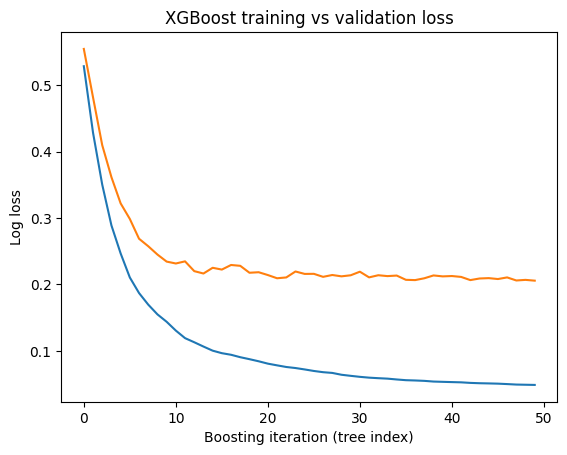

In [5]:
def plot_training(model):
  results = model.evals_result()

  import matplotlib.pyplot as plt

  plt.figure()
  plt.plot(results["validation_0"]["logloss"])
  plt.plot(results["validation_1"]["logloss"])
  plt.xlabel("Boosting iteration (tree index)")
  plt.ylabel("Log loss")
  plt.title("XGBoost training vs validation loss")
  plt.show()
plot_training(model)

## Fixing overfitting

### Early stopping
Each boosting iteration adds one tree.
If validation performance degrades, later trees mostly fit noise.
We can reduce overfitting by **stopping early and using only the first $X$ trees**.


In [6]:
y_pred = model.predict(X_test, iteration_range=(0, 12))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.92      0.96        13

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20




### Hyperparameter tuning
Instead of stopping early, we can **make overfitting harder** by tweaking how the trees are trained.


In [7]:
xgb_params = dict(
    # tree capacity (how complex each tree can be)
    max_depth=3,          # max depth per tree (smaller = weaker trees)
    min_child_weight=5,   # minimum data needed to split (larger = more conservative)
    gamma=1.0,            # minimum loss reduction to split (larger = fewer splits)

    # randomness (variance reduction)
    subsample=0.8,        # fraction of rows per tree
    colsample_bytree=0.8,# fraction of features per tree

    # boosting schedule
    n_estimators=50,     # max number of trees (upper bound)
    learning_rate=0.05,  # contribution of each tree (smaller = slower, safer)
)
model2 = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    **xgb_params,
)


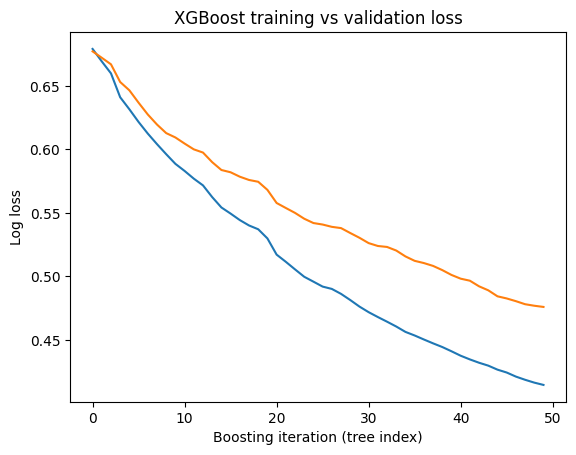

In [8]:
model2.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
plot_training(model2)